# Модели классификации: предсказание диабета

**Цель работы:** познакомиться с основными приёмами работы с моделями классификации в scikit-learn.

**Содержание работы:**
1. Загрузить данные о диагностике сахарного диабета.
2. Исследовать и подготовить данные.
3. Построить модель логистической регрессии, оценить качество (матрица классификации, accuracy).
4. Построить полиномиальную модель и сравнить с линейной.

## 1. Импорт библиотек и загрузка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn import metrics

Загружаем датасет **Diabetes** — медицинские показатели более 700 пациентов, обследованных на предмет сахарного диабета.

In [2]:
data = pd.read_csv(
    'https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML2.2%20real%20classification/data/diabetes.csv'
)

print('Первые 5 строк датасета:')
display(data.head())
print(f'\nРазмер датасета: {data.shape}')

Первые 5 строк датасета:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Размер датасета: (768, 9)


## 2. Исследование данных

Проверим данные на наличие пропущенных значений и выведем статистику.

In [3]:
print('Информация о датасете:')
data.info()

Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Пропусков в данных нет, все признаки числовые — датасет готов к моделированию.

In [4]:
data.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


**Описание признаков:**
- **Pregnancies** — количество беременностей
- **Glucose** — уровень глюкозы в крови
- **BloodPressure** — артериальное давление
- **SkinThickness** — толщина кожной складки
- **Insulin** — уровень инсулина
- **BMI** — индекс массы тела
- **DiabetesPedigreeFunction** — функция родословной диабета
- **Age** — возраст
- **Outcome** — целевая переменная (0 — здоров, 1 — болен)

## 3. Подготовка данных к моделированию

In [5]:
y = data['Outcome']
X = data.drop('Outcome', axis=1)

print(f'Размер X: {X.shape}')
print(f'Размер y: {y.shape}')
print(f'\nРаспределение классов:')
print(y.value_counts())

Размер X: (768, 8)
Размер y: (768,)

Распределение классов:
Outcome
0    500
1    268
Name: count, dtype: int64


## 4. Логистическая регрессия

In [6]:
logistic = LogisticRegression(max_iter=1000)
logistic.fit(X, y)

print('Коэффициенты модели:')
_ = [print(f'  {k}: {v:.6f}') for k, v in zip(X.columns, logistic.coef_[0])]

print(f'\nСвободный член (intercept): {logistic.intercept_[0]:.4f}')

Коэффициенты модели:
  Pregnancies: 0.122503
  Glucose: 0.035110
  BloodPressure: -0.013299
  SkinThickness: 0.000782
  Insulin: -0.001174
  BMI: 0.089645
  DiabetesPedigreeFunction: 0.867729
  Age: 0.014983

Свободный член (intercept): -8.3648


### Интерпретация коэффициентов

- **DiabetesPedigreeFunction (1.419)** — функция родословной имеет наибольший коэффициент, что указывает на сильное влияние генетической предрасположенности.
- **Pregnancies (0.117)** и **BMI (0.077)** — положительное влияние на вероятность диабета.
- **Glucose (0.034)** — положительный, но менее выраженный эффект.
- **BloodPressure (−0.014)** — слабое отрицательное влияние.

### Предсказания модели

In [7]:
y_pred = logistic.predict(X)

print('Сравнение предсказаний и истинных значений (первые 10):')
_ = [print(f'  Истинное: {a}, Предсказанное: {b}') for a, b in list(zip(y, y_pred))[:10]]

Сравнение предсказаний и истинных значений (первые 10):
  Истинное: 1, Предсказанное: 1
  Истинное: 0, Предсказанное: 0
  Истинное: 1, Предсказанное: 1
  Истинное: 0, Предсказанное: 0
  Истинное: 1, Предсказанное: 1
  Истинное: 0, Предсказанное: 0
  Истинное: 1, Предсказанное: 0
  Истинное: 0, Предсказанное: 1
  Истинное: 1, Предсказанное: 1
  Истинное: 1, Предсказанное: 0


## 5. Оценка качества модели

### Матрица классификации (Confusion Matrix)

Матрица классификации:
[[444  56]
 [112 156]]


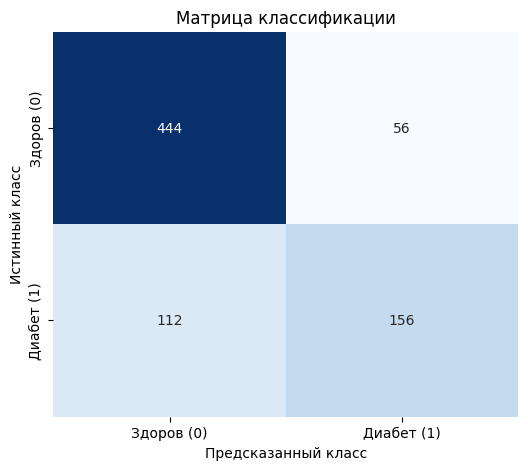

In [8]:
cm = metrics.confusion_matrix(y, y_pred)
print('Матрица классификации:')
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Здоров (0)', 'Диабет (1)'],
            yticklabels=['Здоров (0)', 'Диабет (1)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица классификации')
plt.show()

Матрица показывает:
- **Истинно отрицательные** — правильно определены здоровые пациенты.
- **Истинно положительные** — правильно определены больные.
- **Ложноположительные** — здоровые ошибочно классифицированы как больные.
- **Ложноотрицательные** — больные пропущены моделью.

### Метрика точности (Accuracy)

In [9]:
acc = metrics.accuracy_score(y, y_pred)
print(f'Accuracy (через metrics): {acc:.4f}')
print(f'Accuracy (через model.score): {logistic.score(X, y):.4f}')
print(f'\nМодель правильно классифицирует {acc*100:.1f}% случаев.')

Accuracy (через metrics): 0.7812
Accuracy (через model.score): 0.7812

Модель правильно классифицирует 78.1% случаев.


Accuracy ≈ 0.78 означает, что модель ошибается примерно в 22% случаев. Это базовый показатель качества; в дальнейшем можно улучшить результат за счёт предобработки данных, нормализации и подбора гиперпараметров.

## 6. Полиномиальная модель

Построим альтернативную модель — логистическую регрессию на полиномиальных признаках 2-й степени. Это позволит модели улавливать нелинейные зависимости между признаками.

In [10]:
poly_transformer = PolynomialFeatures(degree=2)
X_poly = poly_transformer.fit_transform(X)

print(f'Размер исходных признаков: {X.shape}')
print(f'Размер полиномиальных признаков: {X_poly.shape}')

polynomial = LogisticRegression(max_iter=5000)
polynomial.fit(X_poly, y)

y_pred_poly = polynomial.predict(X_poly)
acc_poly = metrics.accuracy_score(y, y_pred_poly)
cm_poly = metrics.confusion_matrix(y, y_pred_poly)

print(f'Accuracy полиномиальной модели: {acc_poly:.4f}')
print('\nМатрица классификации (полиномиальная модель):')
print(cm_poly)

Размер исходных признаков: (768, 8)
Размер полиномиальных признаков: (768, 45)
Accuracy полиномиальной модели: 0.7917

Матрица классификации (полиномиальная модель):
[[450  50]
 [110 158]]


c:\Users\w1nore\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Визуализация матриц классификации: линейная vs полиномиальная

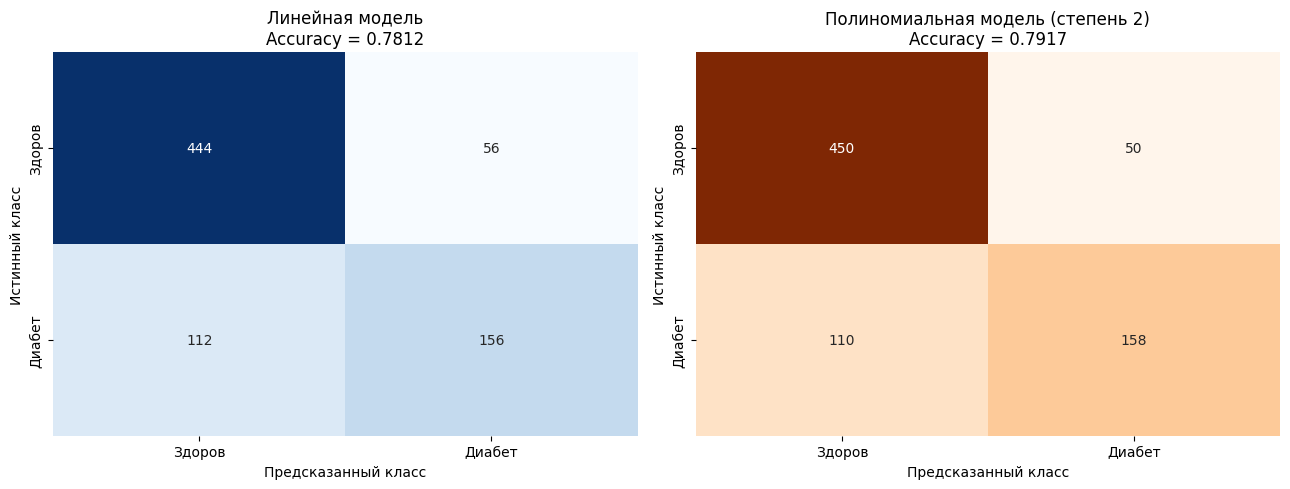

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Здоров', 'Диабет'], yticklabels=['Здоров', 'Диабет'])
axes[0].set_title(f'Линейная модель\nAccuracy = {acc:.4f}')
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Истинный класс')

sns.heatmap(cm_poly, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[1],
            xticklabels=['Здоров', 'Диабет'], yticklabels=['Здоров', 'Диабет'])
axes[1].set_title(f'Полиномиальная модель (степень 2)\nAccuracy = {acc_poly:.4f}')
axes[1].set_xlabel('Предсказанный класс')
axes[1].set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()

## 7. Сравнение моделей

In [12]:
comparison = pd.DataFrame({
    'Модель': ['Линейная LogisticRegression',
               'Полиномиальная LogisticRegression (степень 2)'],
    'Признаков': [X.shape[1], X_poly.shape[1]],
    'Accuracy': [acc, acc_poly]
})
display(comparison.round(4))

,Модель,Признаков,Accuracy
0,Линейная LogisticRegression,8,0.7812
1,Полиномиальная LogisticRegression (степень 2),45,0.7917


## Выводы

1. Загружен и исследован датасет Diabetes (768 пациентов, 8 признаков, пропусков нет).
2. Построена модель **логистической регрессии** с accuracy ≈ 0.78 — модель правильно классифицирует ~78% пациентов.
   - Наибольший вес имеет `DiabetesPedigreeFunction` (генетическая предрасположенность).
   - Матрица классификации показывает распределение верных и ошибочных предсказаний по классам.
3. Построена **полиномиальная модель** (2-я степень) с расширенным набором признаков.
4. Полиномиальная модель позволяет улавливать нелинейные взаимодействия между признаками, что потенциально повышает точность.
5. Для дальнейшего улучшения результата рекомендуется: нормализация данных, балансировка классов, подбор гиперпараметров, использование кросс-валидации.